<span style="font-size: 14px;">

# Neural Networks with PyTorch

In this practical we will learn how to train neural networks using PyTorch, which is a framework for implementing and training neural networks. In particular, we will cover the following concepts:

* PyTorch basics
* Loading a dataset
* Training a multilayer perceptron
* Training a convolutional neural network
* Regularization

In [1]:
import torch # the library that implements the necessary functions and classes for training neural networks
import numpy as np # a library for numerical operations
import torchvision # a library for handling images and videos
import pandas as pd

# Pytorch basics

In [2]:
# let's define a matrix in python
data = [[2,2],[1,1]]
data

[[2, 2], [1, 1]]

In [3]:
# we can convert it into Numpy array using the following
arr = np.array(data)
arr

array([[2, 2],
       [1, 1]])

In [4]:
# we can also convert it into a PyTorch "array", which we generally call as tensor
# Every kind of matrix (whatever be the dimensions) is treated as tensor
torch.Tensor(data)

tensor([[2., 2.],
        [1., 1.]])

In [5]:
# there are special functions to create a tensors of just 1s.
# we just need to specify the dimensions of the tensor
ones = torch.ones((3,5))
ones

tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

In [6]:
# similar as above, but with zeros
zeroes = torch.zeros((3,5))
zeroes

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [7]:
# we can check the shape of a tensor
zeroes.shape

torch.Size([3, 5])

In [8]:
# we can initialize a tensor containing random values
rand = torch.rand((5, 10, 2, 6))
rand.shape

torch.Size([5, 10, 2, 6])

In [9]:
rand.shape

torch.Size([5, 10, 2, 6])

In [10]:
# we can check the data-type of the tensor
rand.dtype

torch.float32

Basic arithmetic using tensors

In [11]:
# Matrix multiplication. multiply two tensors

t1 = torch.rand((3, 2))
t2 = torch.rand((2, 4))

torch.matmul(t1,t2).shape

torch.Size([3, 4])

In [12]:
# another way to do the same, using the @ symbol: t1@t2
r = t1@t2
r

tensor([[0.2809, 0.3855, 0.3951, 0.2289],
        [0.5015, 0.6295, 0.5546, 0.4580],
        [0.5091, 0.5842, 0.4223, 0.5109]])

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

# Loading a dataset

In [13]:
#from torch.utils.data import Dataset

from torchvision import datasets # a package in torch that allows you to download pre-loaded datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt # for visualization

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

## Fashion-MNIST Dataset

The experiments in this notebook use the Fashion-MNIST dataset, a benchmark dataset for image classification tasks introduced by Zalando Research as a more challenging alternative to the classic MNIST handwritten digits dataset.

- Dataset characteristics
    - **Training set:** 60,000 images
    - **Test set:** 10,000 images
    - **Image size:** 28 × 28 pixels
    - **Color space:** grayscale from 0 to 255
    - **Number of classes:** 10

- Each image represents a clothing item or fashion accessory.  
- The target labels are integer values from 0 to 9.
- Tensor representation

In PyTorch, each image is typically represented as a tensor with shape: [1, 28, 28]

In [14]:
#load toy dataset, 10 classes dataset with some clothing, convert data to tensor using the transform parameter

# we load the training data
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor() # to convert the dataset into tensors (remember everything has to be tensor)
)


In [15]:
# we load the test data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [16]:
training_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [17]:
#let's define the labels, just to visualize

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

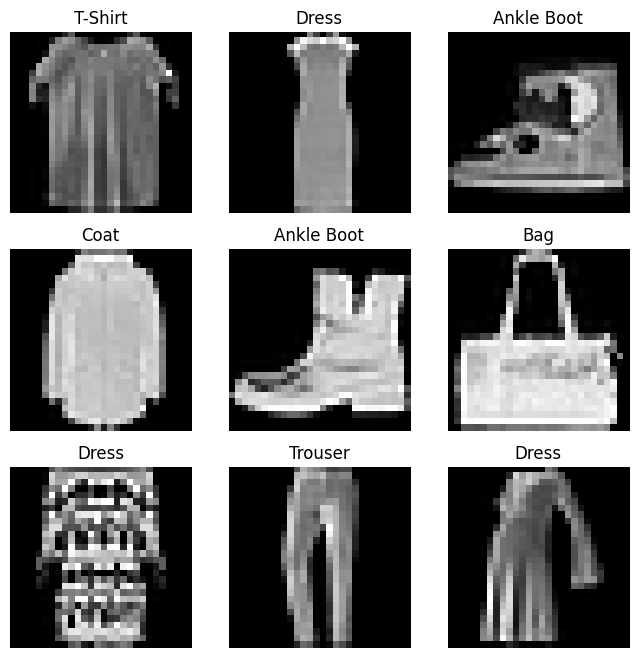

In [18]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [19]:
# now that we have downloaded the dataset, we need to properly load the data
# we need this step because during training we train with mini-batches (recall mini-batch stochastic gradient descent)
# the DataLoader utility allows us to do it (without having to implement the batching by ourselves)

from torch.utils.data import DataLoader

# we create a training dataloader. it will draw mini-batches of size 64 until it finishes all the samples
train_dataloader = DataLoader(
    training_data, # we pass the full training data
    batch_size=64,
    shuffle=True # we shuffle the training data because we want to have some samples of each class in the mini-batch during training
)

# next we will create a test dataloader using the test data
test_dataloader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False # during test we don't really care about shuffling the dataset
)

In [20]:
# how can we draw a mini-batch?
# we create an iterator and get the first item, the iterator will call the __get_item__ with increasing idx from 0 to len-1

train_features, train_labels = next(iter(train_dataloader)) #this is the first batch, so it's 64 items
img = train_features.squeeze()
label = train_labels

print(img.shape) # the shape of the mini-batch is (64, 28, 28) because we have 64 images and each image is 28x28 pixels
print(label.shape) # the shape of the labels is (64,) because we have 64 labels

torch.Size([64, 28, 28])
torch.Size([64])


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

# MLP (Multi-Layer Perceptron)

In machine learning, a neural network (also artificial neural network or neural net, abbreviated ANN or NN) is a computational model inspired by the structure and functions of biological neural networks.

MLPs assume that all input features are independent and equally connected to the next layer, for this reason they are known also as Fully Connected NN (FCNNs).

However, this assumption is inefficient for structured data such as images, where nearby pixels are highly correlated. 
Convolutional NN (CNNs) address this limitation by exploiting local spatial structure through convolutions and shared weights.

| Biological Neuron | Artificial Neuron | Notes |
|-------------------|-------------------| ------|
| Dendrites (dendriti) <br> receive inputs signal $\vec{x}_i$ | Input nodes receive the feature vector $\vec{x_i} \in \mathbb{R}^d$| Input nodes number = feature number = $d$ <br> Number of samples = $N \quad i \in [1,N]$ |
| Cell body (soma) <br> integrates signal | Weighted sum of inputs is computed <br> Weight matrix of hidden layer = $U$ <br> Bias vector of hidden layer = $\vec c$ | single neuron: $\hspace{4em} \underset{1 \times 1}{z_i} = \underset{1 \times d}{\vec{u}^T} \cdot \underset{d \times 1}{\vec{x}_i} + \underset{1 \times 1}{c}$ <br> layer with n neurons: $\quad \underset{n \times 1}{\vec{z_i}} = \underset{n \times d}{U} \cdot \underset{d \times 1}{\vec{x}_i} + \underset{n \times 1}{\vec{c}}$ |
| Threshold triggers firing | Hidden layer Activation function $f(z)$ <br> transforms the signal  (applied element-wise) | ReLU or other non-linear function <br> Number of neurons: hyperparameter |
| Axon (sinapsi) <br> output to next cells | Output Activation function $f_{out}(a)$ <br> computes the output or the input for the next layer <br> Weight matrix of output layer = $W$ <br> Bias vector of output layer = $\vec b$ <br> <br> Regression: 1 neuron (linear output, no activation) <br> Binary Classif: 1 neuron; $f_{out} = $ sigmoid func <br> Multiclass Classif: k neurons; $f_{out} = $ softmax <br> Multilabel Classif: k neurons; $f_{out} = $ independent sigmoid | Binary Classif: $ \hspace{2em} \underset{1 \times 1}{\hat y_i} = f_{out} \left( \underset{1 \times d}{\vec{w}^T} \cdot \underset{d \times 1}{f(\vec{z}_i)} + \underset{1 \times 1}{b} \right)$ <br> <br> Multiclass Classif or <br> Multilabel Classif: $\hspace{1em} \underset {k \times 1}{\hat{\vec y}_i} = f_{out} \left( \underset{k \times d} {W} \, \underset{d \times 1}{f(\vec z_i)} + \underset{k \times 1}{\vec b} \right)$ |

- where: 
$\\$ multiclass: every sample belongs to only one class $\\$ multilabels: every sample can have multiple label (a picture with a dog and a cat)
$\\$ input: $\vec x_i \quad$ target: $t \quad$ pre-activation: $\vec z_i \quad $ activation: $a \\
$ prediction (probability): $\hat y_i \quad$ prediction (class): $y_i \quad$ prediction (real value):$\tilde{y}_i \quad $ raw decision score: $s$
- common **ACTIVATION FUNCTIONS**:
    - perceptron (step func): $\quad f(z_i) = \begin{cases} 0 \ if \ z_i \le 0 \\ 1 \ if \ z_i \gt 0 \end{cases}$ 
    - linear func: $\quad f(z_i) = z_i$
    - tanh func: $ \displaystyle \quad \tanh(z_i) = \frac{\sinh(z_i)}{\cosh{z_i}} = \frac{ e^{z_i} - e^{-z_i}}{e^{z_i}+e^{-z_i}}\\[4pt]$
    - sigmoid func: $ \displaystyle \quad f(z_i) = \frac{1}{1+e^{-z_i}}\\[4pt]$ 
    - softmax func: $\displaystyle \quad f(\vec{z}_i) = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}},  \quad \vec z ∈ \mathbb{R}^K\\[4pt]$ 
    - ReLU func: $ \quad f(z_i) = \max(z_i, 0)$
- common **WEIGHT INITIALIZATION**:
    - If the weights are too small at initialization then they can cause:
        - Vanishing gradients: When gradients become very small as they are backpropagated through many layers, often approaching zero.
        - Recall that backprop involves multiplying gradients with activations. Small weights → small activations → small gradients.
        -  The NN fails to learn. No gradients → no learning!
    - If the weights are too large at initialization then they can cause:
        - Exploding gradients: When gradients become very large as they are propagated backward.
        - Same logic holds here, except the weights are too large, outputs and gradients can grow exponentially across layers.
        - This leads to numerical instability and divergence during training.
    - small random weight (for perceptron): `W = np.random.uniform(-0.01, 0.01, size=(n_out, n_in))`
    - Xavier Initialization (for linear, sigmoid, softmax and tanh): $\quad \displaystyle w \sim U \left(- \sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}} \right)$
    - He Initialization (for ReLU and its variants): $\quad \displaystyle w \sim U \left(- \sqrt{\frac{6}{n_{in} }}, \sqrt{\frac{6}{n_{out}}} \right)$
    -  note: for the output layer, $n_{out}$ corresponds to the number of output classes / labels
- If a layer has multiple neurons, the above functions are applied element-wise to the vector $\vec{z_i}$
- We can have an arbitrary number of hidden layers (i.e., depth) and an arbitrary number of neurons in each hidden layer (i.e., width).
- A network without hidden layers performs linear classification.
- The deeper and wider the network, the more complex the decision boundary becomes.
- It was shown by (Cybenko, 1989) that a MLP (or NN) with a single hidden layer containing enough neurons and a non-linear activation function can approximate any continuous function. This is called the **Universal Approximation Theorem**.
- A NN model is defined by learning all its parameters, including the weight matrices $U$ and bias vectors $\vec{c}$ of each layer. In particular, $U$ and $\vec{c}$ define the hidden layer transformation, while $\vec{w}$ and $b$ define the final decision function. These parameters are jointly optimized:
    - defining a **LOSS FUNCTION** 
        - Classification:
            - Binary with NN: Binary-Cross-Entropy Loss <br>
            $\quad \mathcal{L}_{\text{BCE}}(t, \hat{y}) \triangleq - [t \log{\hat y} + (1-t) \log (1-\hat y)]$
            - Multiclass with NN: Cross-Entropy Loss <br>
            $\quad \mathcal{L}_{\text{CE}}(\vec t, \hat{\vec y}) \triangleq - \sum_{c=1}^C t_c \log(\hat y_c)$ where $t_c$ is the $c^{th}$ component of the one-hot target vector
            - Binary with SVM : Hinge Loss, works for binary classification with labels $t \in \{-1, +1\}$ <br>
            we have to encourage the margin between classes <br>
            $\quad \mathcal{L}_{\text{Hinge}} (t, s) = \max (0,1-t \ s)$
        - Regression:
            - Penalizes large error: Mean Squared Error <br>
            $\quad \mathcal{L}_{\text{MSE}}(\vec t, \tilde {\vec y}) = \frac{1}{N} \sum_{i=1}^N \left( t^{(i)} - \tilde{y}^{(i)}\right)^2$
            - Treats all error equally: Mean Absolute Error <br>
            $\quad \mathcal{L}_{\text{MAE}}(\vec t, \tilde {\vec y}) = \frac{1}{N} \sum_{i=1}^N \left| t^{(i)} - \tilde{y}^{(i)}\right|$
            - Combines MSE (for small errors) and MAE (for large errors) <br>
            $\quad \mathcal{L}_{\text{Huber}}(\vec t, \tilde {\vec y}) = \frac{1}{N} \sum_{i=1}^N \mathcal{l}_{\text{Huber}}^{(i)} (t^{(i)}, \tilde {y}^{(i)})\\[6pt]
            \quad \mathcal{l}^{(i)}_{\text{Huber}} (t^{(i)}, \tilde {y}^{(i)}) = \begin{cases} 0.5 \left( a^{(i)} \right)^2 \hspace{3em} \left| a^{(i)} \right| \le \delta \text{ (small errors)}\\ \delta \ ( |a^{(i)}| - 0.5 \ \delta ) \hspace{1em} \text{otherwise (large errors)} \end{cases} \\[6pt]
            \quad a^{(i)} = t^{(i)} - \tilde{y}^{(i)} \\
            \quad \delta =$ threshold
        
    - using an **OPTIMIZATION ALGORITHM**
        - (Full) Batch GD:
            - Model parameters are updated after processing the entire training dataset
            - Stable and accurate
            - Slow, requires a lot of memory, can get stuck in local minima <br>
            $ \hspace{3em} g_t := \frac{1}{N} \sum_{i=1}^N \nabla_{\vec{w}} \mathcal{L}^{(i)} \\[4pt]
            \hspace{3em} \vec{w}_{t+1} := \vec{w}_t - \gamma g_t \\
            \hspace{3em} \gamma: $ learning rate (hyper parameter)
       - Stochastic GD:
            - Model parameters are updated after processing one sample
            - Faster and can escape local minima
            - Noisy and updates are less accurate <br>
            $ \hspace{3em} g_t := \nabla_{\vec{w}}  \mathcal{L}^{(i)} \ $ where $ \ i \in [1..N] \\
            \hspace{3em} \vec{w}_{t+1} := \vec{w}_t - \gamma \ g_t \\
            \hspace{3em} \gamma: $ learning rate (hyper parameter)
        - Minibatch GD:
            - Model parameters are updated after processing a mini-batch of samples (say 64)
            - Best of both worlds: Less prone to oscillations compared to SGD, and faster than GD. <br>
            $ \hspace{3em} g_t := \frac{1}{m} \sum_{i=1}^m \nabla_{\vec{w}} \mathcal{L}^{(i)}  \ $ where $ \ 1 \le m \le N \\[4pt]
            \hspace{3em} \vec{w}_{t+1} := \vec{w}_t - \gamma \ g_t \\
            \hspace{3em} \gamma: $ learning rate (hyper parameter)
        - Minibatch GD or SGD with Momentum:
            - Add inertia to the updates
            - Faster convergence <br>
            $ \hspace{3em} g_t \ $ as above $\\
            \hspace{3em} \vec{v}_{t+1} := \beta \ \vec{v}_t + (1- \beta) \ g_t \ $ where $ \ 0 \le \beta \le 1 \\
            \hspace{3em} \vec{w}_{t+1} := \vec{w}_t - \gamma \ \vec{v}_{t+1} \\
            \hspace{3em} \beta: $ momentum coefficient (hyper parameter) $\\
            \hspace{3em} \gamma: $ learning rate (hyper parameter)
    - eventually using a **LEARNING RATE UPDATE FUNCTION** (scheduler in PyTorch)
        - Exponential decay:
            - Adjusts the learning rate (the same for all the parameters). <br>
            $\hspace{3em} \gamma_t = \gamma \cdot \exp (-\beta \ t) \\
             \hspace{3em} \beta = $ decay rate (hyper parameter) $ \\
             \hspace{3em} \gamma: $ initial learning rate (hyper parameter)
        - Inverse decay:
            - Adjusts the learning rate (the same for all the parameters). <br>
            $\hspace{3em} \displaystyle \gamma_t = \frac{\gamma} {1 + \beta \ t} \\
             \hspace{3em} \beta = $ decay rate (hyper parameter) $ \\
             \hspace{3em} \gamma: $ initial learning rate (hyper parameter)
    - or using an **ADAPTIVE OPTIMIZATION ALGORITHM**
        - AdaGrad can be used with GD, SGD, but is often used with Minibatch GD :
            - Adjusts the learning rate for each $r^{th}$ parameter, $\quad r \in [1..d]$
            - No need to tune learning rate, as it decays over time <br>
            $ \hspace{3em} \displaystyle g_{t,r} := \frac{\partial \mathcal{L}}{\partial w_r} \Big |_t \\[4pt]
            \hspace{3em} G_{t,r} := \sum_{j=0}^t \left(g_{j,r}\right)^2 \\[4pt]
            \hspace{3em} \displaystyle \gamma_{t+1,r} = \frac{ \gamma}{\sqrt{G_{t,r} + \epsilon}} \\
            \hspace{3em} w_{t+1, r} := w_{t,r} - \gamma_{t+1,r} \ g_{t,r} \\[4pt]
            \hspace{3em} \epsilon: $ numerical stability term $ \approx 10^{-8} $ (hyper parameter) $ \\
            \hspace{3em} \gamma: $ initial learning rate (hyper parameter)
        - RMSProp (Root Mean Square Propagation), usually with Minibatch GD:
            - Adapts the learning rate for each parameter using an exponentially decaying average of squared gradients
            - Prevents the learning rate from decaying too aggressively (unlike AdaGrad)
            - Works well for non-stationary objectives <br>
            $ \hspace{3em} \displaystyle g_{t,r} := \frac{\partial \mathcal{L}}{\partial w_r} \Big |_t \\[4pt]
            \hspace{3em} v_{t+1,r} := \beta \ v_{t,r} + (1-\beta) \ \left(g_{t,r}\right)^2 \\[6pt]
            \hspace{3em} \displaystyle \gamma_{t+1,r} := \frac{\gamma}{\sqrt{v_{t+1,r}} + \epsilon} \\[8pt]
            \hspace{3em} w_{t+1,r} := w_{t,r} - \gamma_{t+1,r} \ g_{t,r} \\[4pt]
            \hspace{3em} \beta: $ squared-gradient decay rate (hyper parameter), usually $ \approx 0.9 \\ 
            \hspace{3em} \epsilon: $ numerical stability term $ \approx 10^{-8} $ (hyper parameter) $ \\
            \hspace{3em} \gamma: $ initial learning rate (hyper parameter)
        - Adam (Adaptive Moment Estimation), usually with Minibatch GD:
            - Combines momentum and adaptive learning rates (AdaGrad/RMSProp style)
            - Keeps an exponentially decaying average of both gradients and squared gradients
            - Fast convergence and robust in practice <br>
            $ \hspace{3em} \displaystyle g_{t,r} := \frac{\partial \mathcal{L}}{\partial w_r} \Big |_t \\[4pt]
            \hspace{3em} m_{t+1,r} := \beta_1 \ m_{t,r} + (1-\beta_1) \ g_{t,r} \\[4pt]
            \hspace{3em} v_{t+1,r} := \beta_2 \ v_{t,r} + (1-\beta_2) \ \left( g_{t,r} \right)^2 \\[4pt]
            \hspace{3em} \hat m_{t+1,r} := \frac{m_{t+1,r}}{1-\left(\beta_1\right)^{t+1}} \\[8pt]
            \hspace{3em} \hat v_{t+1,r} := \frac{v_{t+1,r}}{1-\left(\beta_2\right)^{t+1}} \\[8pt]
            \hspace{3em} \displaystyle \gamma_{t+1,r} := \frac{\gamma}{\sqrt{\hat v_{t+1,r}} + \epsilon} \\[8pt]
            \hspace{3em} w_{t+1,r} := w_{t,r} - \gamma_{t+1,r} \ \hat m_{t+1,r} \\[4pt]
            \hspace{3em} \beta_1: $ momentum decay rate (hyper parameter), usually $ \approx 0.9 \\ 
            \hspace{3em} \beta_2: $ squared-gradient decay rate (hyper parameter), usually $ \approx 0.999 \\ 
            \hspace{3em} \epsilon: $ numerical stability term $ \approx 10^{-8} $ (hyper parameter) $ \\
            \hspace{3em} \gamma: $ initial learning rate (hyper parameter)

    - gradient-based optimization requires differentiable functions (e.g., ReLU is piecewise differentiable)
    - gradients are computed using backpropagation, conceptually: <br>
    $ \hspace{3em} \displaystyle \frac{\partial \mathcal{L}}{\partial \vec{w}} = \frac{\partial \mathcal{L}}{\partial a_L} \ \prod_{l=L}^{1} \frac{\partial a_l}{\partial z_l} \ \frac{\partial z_l}{\partial \vec{w}} \quad$ where 
        - $L$ hidden layers number + 1 (output layer), 
        - $a_l$ signal at the end of $l^{th}$ layer
        - Gradient computation follows the chain rule decomposition: <br>
        $\quad$ gradient = local gradient × upstream gradient <br>
        which corresponds to the sequential product of partial derivatives along the computational graph.
        - Backpropagation is an algorithm for propagating gradients on a directed acyclic computational graph (DAG). It is based on the chain rule and implemented as a reverse topological traversal, from outputs back to inputs.
        - Backpropagation is analogous to dynamic programming: it avoids redundant computations by storing intermediate results (gradients of sub-expressions), similarly to the Fibonacci recursion optimization. However, it operates on a computational graph where gradients are propagated backward and aggregated across multiple paths.


---

<span style="font-size: 14px;">

## Common PyTorch implementations:

| Concept | PyTorch Code | Notes |
|---|---|---|
| Binary Cross Entropy Loss | `nn.BCELoss()` | Requires sigmoid output probabilities |
| Binary Cross Entropy with logits | `nn.BCEWithLogitsLoss()` | More numerically stable; combines sigmoid + BCE |
| Cross Entropy Loss | `nn.CrossEntropyLoss()` | Multiclass classification; expects raw logits |
| Hinge Loss | `nn.MultiMarginLoss()` | SVM |
| Mean Squared Error | `nn.MSELoss()` | Regression (MSE) |
| Mean Absolute Error | `nn.L1Loss()` | Regression (MAE) |
| Huber Loss | `nn.HuberLoss(delta=1.0)` | Regression |
| SGD Optimizer | `torch.optim.SGD(model.parameters(), lr=0.01)` | Basic gradient descent |
| SGD with Momentum | `torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` | Adds momentum term |
| AdaGrad Optimizer | `torch.optim.Adagrad(model.parameters(), lr=0.01)` | Adaptive learning rate |
| RMSProp Optimizer | `torch.optim.RMSprop(model.parameters(), lr=0.001)` | Uses moving average of squared gradients |
| Adam Optimizer | `torch.optim.Adam(model.parameters(), lr=0.001)` | Most commonly used optimizer |
| Exponential LR Decay | `torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)` | Multiplicative decay |
| Inverse / Step Decay | `torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)` | Reduces LR every fixed number of epochs |


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

# Training a Multi-layer Perceptron (MLP)

In [21]:
from torch import nn # the nn library, which stands for neural networks, implements everything related to training neural networks

In [22]:
nn.Linear(10, 12).bias # this is the bias of a linear layer with 10 input features and 12 output features. The bias is a vector of size 12, one for each output feature.

Parameter containing:
tensor([ 0.1747,  0.0672, -0.2188,  0.1769,  0.2044,  0.1515, -0.2899, -0.2754,
        -0.0755, -0.2387,  0.2058, -0.0784], requires_grad=True)

In [23]:
# the first step is to define or design the neural network
# we will create a simple neural network with the following architecture:
# 1 hidden layer (or Linear layer) --> ReLU --> 2nd hidden layer --> ReLU --> output layer

# note that we have images of shape 28 x 28 (or two dimensional matrices). we need to first flatten them into a long vector.
# 28 x 28 = 784 (input features) -> 512 (first hidden layer) -> 128 (second hidden layer, more semantic features) -> 10 (output features)

class NeuralNetwork(nn.Module):
    # this is where we define the architecture
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten() # this layer will flatten the input images from (28, 28) to (28*28,) or (784,)

        self.fc_relu = nn.Sequential(
            nn.Linear(28*28, 512), # a linear layer takes two arguments: number of input neurons (eg., 28*28) and number of output neurons (eg, 512)
            nn.ReLU(), # ReLu for the first hidden layer
            nn.Linear(512, 128), #512 and 128 are arbitrary numbers between 10 and 28*28
            nn.ReLU(), # ReLu for the second hidden layer
            nn.Linear(128, 10) # number of output neurons is 10 because we have a 10-class classification problem
            # Output Activation function will be applied later 
        )
        
    # this is where we define the forward pass, ie., telling the flow of data through the network
    def forward(self, x):
        x = self.flatten(x)
        logits = self.fc_relu(x)
        return logits

In [24]:
# initialize the network
model = NeuralNetwork() # create an instance of the NeuralNetwork class
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_relu): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [25]:
# let see a demo forward pass, how we can compute the output probability

logits = model(img) #get output from the model
print(logits.shape)

pred_prob = nn.Softmax(dim=1)(logits) # convert output to a probability
print(pred_prob.shape)

pred_prob[0:5].sum(dim=1) # check, for the first 5 samples, that the probabilities sum = 1

torch.Size([64, 10])
torch.Size([64, 10])


tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)

In [26]:
# we need to define a loss function and an optimizer (the same for all the layers)
# every layer will own a specific weight matrix e nd bias vector 

loss_function = nn.CrossEntropyLoss() #cross entropy since it's a classification task

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01) # optimizer, Adam, SGD, etc...

In [27]:
# we define the training function
# in summary the training function will do the following:
# 1. load a mini-batch using the dataloader
# 2. do a forward pass on the mini-batch
# 3. calculate the loss
# 4. do backpropagation to compute the gradients
# 5. update the weights

def train(model, train_dataloader, loss_function, optimizer):
    model.train() #set model in training mode
    samples = 0
    cumulative_loss = 0
    cumulative_accuracy = 0
    for input_data, targets in train_dataloader: # load the mini-batches
        outputs = model(input_data) # forward pass
        optimizer.zero_grad() #reset optimizer value, need to do it each epoch
        loss = loss_function(outputs, targets) # compute the loss on the mini-batch
        loss.backward() # pass the loss information back or backpropagation
        optimizer.step() # apply optimizer or we update the weights
        samples += len(input_data) #update countes
        cumulative_loss += loss.item() # update loss value
        _, predicted = outputs.max(1) #max returns both values and indexes, we only take indexes which are the classes
        cumulative_accuracy += predicted.eq(targets).sum().item()
    #print(f'loss: {cumulative_loss/samples}, accuracy: {cumulative_accuracy/samples*100}')
    return cumulative_loss/samples, cumulative_accuracy/samples*100

# this is a test function that does similar things, except it only evaluates the model
def test(model, test_dataloader, loss_function):
    samples = 0.
    cumulative_loss = 0.
    cumulative_accuracy = 0.

    model.eval() # Strictly needed if network contains layers which has different behaviours between train and test
    with torch.no_grad(): # dont compute gradiens
        for input_data, targets in test_dataloader:
            # Forward pass
            outputs = model(input_data)

            # Apply the loss
            loss = loss_function(outputs, targets)

            # Better print something
            samples+=len(input_data)
            cumulative_loss += loss.item() # Note: the .item() is needed to extract scalars from tensors
            _, predicted = outputs.max(1)
            cumulative_accuracy += predicted.eq(targets).sum().item()

    return cumulative_loss/samples, cumulative_accuracy/samples*100

<span style="font-size: 14px;">

---

## Epochs

Typically we don't go through the training dataset just one, but we do it several times in a loop
every time we have finished using all the samples in the dataset, we say that we have completed on "epoch"
typically, we train the network for several epochs. 

Each epoch will start using the model with the weights updated from the previous epoch, 
and we will see how the loss and accuracy evolve across epochs.

* **Epochs vs Hidden Layers (key distinction)**
  Epochs and hidden layers control two completely different aspects of a neural network.

* **Epochs (training duration)**
  An epoch corresponds to one full pass over the entire training dataset. Increasing the number of epochs does not change the model architecture or its capacity; it only allows the same model to be optimized for a longer time using gradient-based updates. More epochs generally improve performance up to a point, after which the model may start to overfit the training data.

* **Hidden layers (model capacity)**
  Hidden layers define the architecture of the neural network. Increasing the number of hidden layers increases the model’s representational power, allowing it to learn more complex functions and decision boundaries. This is a structural change made before training starts.

* **Intuition**

  * Epochs control *how long the model learns*.
  * Hidden layers control *what the model is capable of learning*.

* **Effect in practice**

  * Increasing epochs improves optimization of the same function (risk: overfitting).
  * Increasing hidden layers changes the function class the model can represent (higher capacity, higher flexibility, but also higher risk of overfitting if not regularized).



In [28]:
# lets test the model before training
test_loss, test_accuracy = test(model, test_dataloader, loss_function)
print('Before training anything')
print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
print('-----------------------------------------------------')

# now lets train for 5 epochs
epochs = 5
for e in range(epochs):
    train_loss, train_accuracy = train(model, train_dataloader, loss_function, optimizer)  
    # the model is not re-initialized, so it will keep the weights updated from the previous epoch
    test_loss, test_accuracy = test(model, test_dataloader, loss_function)
    print('Epoch: {:d}'.format(e))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(test_loss, test_accuracy))
    print('-----------------------------------------------------')

Before training anything
	 Test loss 0.03616, Test accuracy 10.74
-----------------------------------------------------
Epoch: 0
	 Training loss 0.00827, Training accuracy 80.80
	 Validation loss 0.00722, Validation accuracy 83.84
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00643, Training accuracy 85.18
	 Validation loss 0.00705, Validation accuracy 84.25
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00604, Training accuracy 86.02
	 Validation loss 0.00640, Validation accuracy 85.65
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00590, Training accuracy 86.36
	 Validation loss 0.00651, Validation accuracy 85.44
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00562, Training accuracy 87.05
	 Validation loss 0.00716, Validation accuracy 84.21
-----------------------------------------------------


<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

# CNNs (Convolutional Neural Networks)

![LeNet-5 Architecture](https://upload.wikimedia.org/wikipedia/commons/thumb/3/35/LeNet-5_architecture.svg/1920px-LeNet-5_architecture.svg.png)

Here we are going to define our first CNN which is **LeNet** in this case, its called LeNet because it was introduced by a researcher called Yann Lecunn. 

To construct a LeNet we will be using some convolutional layers followed by some fully-connected layers. The convolutional layers can be simply defined using `torch.nn.Conv2d` module of `torch.nn` package. Details can be found [here](https://pytorch.org/docs/stable/nn.html#conv2d). 

Moreover, we will use pooling operation to reduce the size of convolutional feature maps. For this case we are going to use `torch.nn.functional.max_pool2d`. Details about maxpooling can be found [here](https://pytorch.org/docs/stable/nn.html#max-pool2d)

Differently from our previous Lab, we will use a Rectified Linear Units (ReLU) as activation function with the help of `torch.nn.functional.relu`, replacing `torch.nn.Sigmoid`. Details about ReLU can be found [here](https://pytorch.org/docs/stable/nn.html#id26).



| Biological Neuron | Artificial Neuron | Notes |
|-------------------|-------------------| ------|
| I neuroni della corteccia visiva primaria (V1) sono sensibili <br> solo a piccole regioni specifiche del campo visivo. <br> Rispondono a stimoli semplici come linee, bordi o <br> angoli orientati in una certa direzione | I filtri (o kernel) nei layer convoluzionali <br> imitano questo comportamento. Elaborano porzioni <br> limitate dell'immagine di input (campi recettivi), <br> rilevando caratteristiche di basso livello come bordi, <br> gradienti di colore e angoli <br> $X$: input image / feature map <br> $K$: convolution kernel (filter) <br> $S$: output feature map <br>| I Campi Recettivi e le Convoluzioni <br> (Local receptive fields) <br><br> Convoluzione discreta 2D: <br> $ S(i,j)= (X * K)(i,j)$ |
| L'informazione visiva viaggia in modo gerarchico. <br> Da V1, i segnali passano ad aree visive superiori <br> (V2, V4, ecc.), dove l'elaborazione diventa sempre <br> più complessa e astratta, permettendoci di <br> riconoscere oggetti complessi indipendentemente <br> dalle dimensioni o dall'orientamento |  I layer di una CNN sono strutturati in una gerarchia visiva: <br> - Layer iniziali: Rilevano linee e contorni semplici. <br>- Layer intermedi: Combinano i pattern semplici per <br> riconoscere forme geometriche complesse <br> (es. ruote di un'auto, occhi di un viso). <br>- Layer finali (Fully Connected): Integrano le <br> informazioni  per classificare l'intera immagine.| Organizzazione Gerarchica <br> ( Hierarchical feature extraction) <br> Ogni layer costruisce feature sempre più astratte <br> <br> Input $\rightarrow \\ \big[ $ Conv $\rightarrow$ ReLU $\rightarrow$ Pooling $\big]_{\text{repeat}}\rightarrow \\ $ FCNNs $\rightarrow$ Linear Classifier $\rightarrow$ Softmax $\rightarrow$ Output  |
| I neuroni biologici nelle aree visive superiori <br> mostrano invarianza traslazionale; <br> sono cioè in grado di riconoscere un oggetto <br> (come una sedia) anche se questo si sposta in <br> un'altra parte del campo visivo. |  Il processo di Pooling esegue un sottocampionamento <br> dei dati, riducendo le dimensioni spaziali dell'immagine. <br> Questo comprime le informazioni, rende il modello <br> più efficiente e garantisce che la rete riconosca le <br> caratteristiche indipendentemente dalla loro esatta <br> posizione nell'immagine (invarianza). | I Layer di Pooling e l'Invarianza <br> (Translation invariance) <br> <br> $P(i,j)=\underset {(m,n) \in \mathcal{R}_{ij}}  {\max} S(m,n)$ <br><br> $\mathcal{R}_{ij}$: regione locale della feature map|
| Nel cervello, lo stesso "circuito" neuronale o cluster <br> di neuroni viene riutilizzato per analizzare parti <br> diverse dell'ambiente visivo, invece di creare un <br> nuovo  circuito per ogni singolo pixel. | Nella convoluzione, lo stesso filtro (matrice di pesi)  <br> viene fatto scorrere su tutta l'immagine. <br> Questo riduce drasticamente il numero di parametri <br> che la rete deve apprendere, imitando l'efficienza <br> computazionale del nostro cervello | Condivisione dei Pesi <br> (Weight Sharing) <br> <br> Un singolo kernel $K$ viene applicato a <br> tutte le posizioni spaziali: <br>$ S(i,j)=(X * K)(i,j) $ <br> Gli stessi pesi del kernel sono condivisi <br> globalmente,  a differenza delle FCNN <br> dove ogni connessione ha pesi distinti|

- where: 
$ \\ S(i,j)= (X * K)(i,j) = \sum_m \sum_n X_{i+m, \ j+n} \ K_{m,n} = \sum_m \sum_n X_{m, \ n} \ K_{i-m, \ j-n} \hspace{2em}$ `S = F.conv2d(X, K) `
$\\ H_{in},W_{in} =$ altezza e larghezza input <br>
$ H_{out},W_{out} =$ altezza e larghezza output <br>
$ K_h, K_w =$ altezza e larghezza kernel <br>
$ P_h, P_w =$ padding (bordo) verticale/orizzontale <br>
$ S_h, S_w =$ stride (spostamento) verticale/orizzontale <br>
$ \displaystyle  H_{out} = \left\lfloor \frac{H_{in} + 2P_h - K_h}{S_h} \right\rfloor + 1 \hspace{2em} W_{out} = \left\lfloor \frac{W_{in} + 2P_w - K_w}{S_w} \right\rfloor + 1$

In [29]:
import torch.nn.functional as F
from torchvision import transforms as T

In [30]:
nn.Conv2d(1, 6, kernel_size=(3,3), padding=1)

Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [31]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()

    # input channel = 1, output channels = 6, kernel size = 5
    # input image size = (28, 28), image output size = (24, 24) --> (12,12) dopo max pool
    self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=(5,5))

    # input channel = 6, output channels = 16, kernel size = 5
    # input image size = (12x12), output image size = (8, 8) --> (4x4) dopo max pool
    self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5,5))

    # input dim = ? (4 x 4 x16), output dim = 120
    self.fc1 = torch.nn.Linear(in_features=4*4*16, out_features=120)

    # input dim = 120, output dim = 84
    self.fc2 = torch.nn.Linear(in_features=120, out_features=84)

    # input dim = 84, output dim = 10
    self.fc3 = torch.nn.Linear(in_features=84, out_features=10)

  def forward(self, x):
      
      x = self.conv1(x)
      x = F.relu(x)
      x = F.max_pool2d(x, kernel_size=2) # Max Pooling with kernel size = 2
      # output size = (12, 12)

      x = self.conv2(x)
      x = F.relu(x)
      x = F.max_pool2d(x, kernel_size=2) # Max Pooling with kernel size = 2
      # output size = (4, 4)
      
      x = x.view(x.shape[0], -1) # flatten the feature maps into a long vector or flattening

      x = self.fc1(x)
      x = F.relu(x)

      x = self.fc2(x)
      x = F.relu(x)

      logits = self.fc3(x)

      return logits

In [32]:
LeNet()

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

## Define the function that fetches a data loader that is then used during iterative training.

We will learn a new thing in this function as how to Normalize the inputs given to the network.

***Why Normalization is needed***?

To have nice and stable training of the network it is recommended to normalize the network inputs between \[-1, 1\].

***How it can be done***?

This can be simply done using `torchvision.transforms.Normalize()` transform. Details can be found [here](https://pytorch.org/docs/stable/torchvision/transforms.html#torchvision.transforms.Normalize).

In [33]:
def get_data(batch_size, test_batch_size=64):

  # Prepare data transformations and then combine them sequentially
  transform = list()
  transform.append(T.ToTensor())                            # converts Numpy to Pytorch Tensor
  transform.append(T.Normalize(mean=[0.5], std=[0.5]))      # Normalizes the Tensors between [-1, 1]
  transform = T.Compose(transform)                          # Composes the above transformations into one.

  # Load data
  
  full_training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform # we add our customized transformation function
  )

  test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
  )

  # here we want to further split the training set into train and val set
  # Create train and validation splits
  num_samples = len(full_training_data)
  training_samples = int(num_samples*0.8+1)
  validation_samples = num_samples - training_samples

  training_data, validation_data = torch.utils.data.random_split(full_training_data, [training_samples, validation_samples])

  # Initialize dataloaders
  train_loader = torch.utils.data.DataLoader(training_data, batch_size, shuffle=True) # 80% of training data for training
  val_loader = torch.utils.data.DataLoader(validation_data, test_batch_size, shuffle=False) # 20% of training data for validation
  test_loader = torch.utils.data.DataLoader(test_data, test_batch_size, shuffle=False) # 100% of test data for testing

  return train_loader, val_loader, test_loader

In [34]:
# same as before, except now we will use the GPU to train our model because its faster than running the cpu

def test(net, data_loader, cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.

  net.eval() # Strictly needed if network contains layers which has different behaviours between train and test
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(data_loader):
      # Load data into GPU
      inputs = inputs.to(device)
      targets = targets.to(device)

      # Forward pass
      outputs = net(inputs)

      # Apply the loss
      loss = cost_function(outputs, targets)

      # Better print something
      samples+=inputs.shape[0]
      cumulative_loss += loss.item() # Note: the .item() is needed to extract scalars from tensors
      _, predicted = outputs.max(1)
      cumulative_accuracy += predicted.eq(targets).sum().item()

  return cumulative_loss/samples, cumulative_accuracy/samples*100


def train(net,data_loader,optimizer,cost_function, device='cuda:0'):
  samples = 0.
  cumulative_loss = 0.
  cumulative_accuracy = 0.

  net.train() # Strictly needed if network contains layers which has different behaviours between train and test
  for batch_idx, (inputs, targets) in enumerate(data_loader):
    # Load data into GPU
    inputs = inputs.to(device)
    targets = targets.to(device)

    # Forward pass
    outputs = net(inputs)

    # Apply the loss
    loss = cost_function(outputs,targets)

    # Reset the optimizer
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    # Better print something, no?
    samples+=inputs.shape[0]
    cumulative_loss += loss.item()
    _, predicted = outputs.max(1)
    cumulative_accuracy += predicted.eq(targets).sum().item()
  return cumulative_loss/samples, cumulative_accuracy/samples*100

In [35]:
''' def main()
Input arguments
  batch_size: Size of a mini-batch
  device: GPU where you want to train your network
  weight_decay: Weight decay co-efficient for regularization of weights
  momentum: Momentum for SGD optimizer
  epochs: Number of epochs for training the network
'''

def main(batch_size=128,
         device='cuda:0',
         learning_rate=0.01,
         weight_decay=0.000001,
         momentum=0.9,
         epochs=10):

  train_loader, val_loader, test_loader = get_data(batch_size)

  net = LeNet().to(device) # send the model to the GPU
  optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

  cost_function = nn.CrossEntropyLoss()

  print('Before training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function, device)
  val_loss, val_accuracy = test(net, val_loader, cost_function, device)
  test_loss, test_accuracy = test(net, test_loader, cost_function, device)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

  for e in range(epochs):
    train_loss, train_accuracy = train(net, train_loader, optimizer, cost_function, device)
    val_loss, val_accuracy = test(net, val_loader, cost_function, device)
    print('Epoch: {:d}'.format(e+1))
    print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
    print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
    print('-----------------------------------------------------')

  print('After training:')
  train_loss, train_accuracy = test(net, train_loader, cost_function)
  val_loss, val_accuracy = test(net, val_loader, cost_function)
  test_loss, test_accuracy = test(net, test_loader, cost_function)

  print('\t Training loss {:.5f}, Training accuracy {:.2f}'.format(train_loss, train_accuracy))
  print('\t Validation loss {:.5f}, Validation accuracy {:.2f}'.format(val_loss, val_accuracy))
  print('\t Test loss {:.5f}, Test accuracy {:.2f}'.format(test_loss, test_accuracy))
  print('-----------------------------------------------------')

In [36]:
main() # device='cpu' for training on the cpu

Before training:
	 Training loss 0.01805, Training accuracy 10.15
	 Validation loss 0.03612, Validation accuracy 9.42
	 Test loss 0.03618, Test accuracy 10.00
-----------------------------------------------------
Epoch: 1
	 Training loss 0.00863, Training accuracy 59.29
	 Validation loss 0.01207, Validation accuracy 69.85
-----------------------------------------------------
Epoch: 2
	 Training loss 0.00414, Training accuracy 79.82
	 Validation loss 0.00814, Validation accuracy 80.31
-----------------------------------------------------
Epoch: 3
	 Training loss 0.00345, Training accuracy 83.55
	 Validation loss 0.00663, Validation accuracy 84.26
-----------------------------------------------------
Epoch: 4
	 Training loss 0.00301, Training accuracy 85.65
	 Validation loss 0.00636, Validation accuracy 85.43
-----------------------------------------------------
Epoch: 5
	 Training loss 0.00279, Training accuracy 86.84
	 Validation loss 0.00612, Validation accuracy 85.77
----------------

<div style="page-break-before: always;"></div>

---

<span style="font-size: 14px;">

# Build a MLP and CNN for KMNIST dataset (Homework)

https://github.com/rois-codh/kmnist/tree/master

Pytorch: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.KMNIST.html#torchvision.datasets.KMNIST

Go to PyTorch documentation, where you will find all other pre-prepared dataset

https://docs.pytorch.org/vision/stable/datasets.html

Also try Eurosat, and Cifar10 --> 3 input channels


In [37]:
# ============================================================================
# PARAMETRIC CODE: MLP and CNN for ANY dataset
# Automatically deduces: num_channels, image_size, num_classes
# ============================================================================
def load_dataset_split(dataset_name, transform, train_ratio=0.8, msg=True):
    """
    Load a torchvision dataset handling both:
    - datasets with built-in train/test split
    - datasets requiring manual split (e.g. EuroSAT)
    Returns:
    - train_data
    - test_data
    """

    dataset_class = getattr(datasets, dataset_name)

    try:
        # Standard datasets (MNIST, CIFAR10, KMNIST, ...)
        train_data = dataset_class(root='data',train=True,download=True,transform=transform)
        test_data = dataset_class(root='data',train=False,download=True,transform=transform)

    except TypeError:
        # Datasets without train/test argument (EuroSAT, ...)
        if msg:
            print(f"  {dataset_name} doesn't use train/test split, using manual split...")

        full_data = dataset_class(root='data',download=True,transform=transform)
        num_samples = len(full_data)
        train_samples = int(num_samples * train_ratio)
        test_samples = num_samples - train_samples
        train_data, test_data = torch.utils.data.random_split(full_data,[train_samples, test_samples])

    return train_data, test_data

def get_dataset_parametric(dataset_name, train_batch_size, test_batch_size):
    """
    Load any dataset and automatically deduce its properties   
    Returns:
    - train_loader, val_loader, test_loader : DataLoaders
    - dataset_info : dict with 'n_channels', 'image_size', 'num_classes'
    """
    
    # First load with basic transform to detect properties
    transform_temp = T.ToTensor()
    
    print(f"Loading {dataset_name}...")
    train_data_temp, test_data_temp = load_dataset_split(dataset_name, transform_temp)

    # Deduce properties from first sample
    sample_img, sample_label = train_data_temp[0]
    n_channels = sample_img.shape[0]
    image_size = sample_img.shape[1]  # Assumes square images
    
    # Get number of classes
    all_labels = set()
    for _, label in train_data_temp:
        all_labels.add(label)
    num_classes = len(all_labels)
    
    print(f"Dataset Info: {n_channels} channels, {image_size}x{image_size} images, {num_classes} classes\n")
    
    # Create normalization automatically based on number of channels
    normalize = T.Normalize(mean=[0.5] * n_channels, std=[0.5] * n_channels)
    
    # Create the full transform with normalization
    transform = T.Compose([T.ToTensor(), normalize])
    
    # Reload with proper normalization
    train_data, test_data = load_dataset_split(dataset_name, transform, msg=False)

    # Split train/val 80/20
    num_samples = len(train_data)
    training_samples = int(num_samples * 0.8 + 1)
    validation_samples = num_samples - training_samples
    training_data, validation_data = torch.utils.data.random_split(train_data, [training_samples, validation_samples])
    
    # Create DataLoaders
    train_loader = DataLoader(training_data, train_batch_size, shuffle=True)
    val_loader = DataLoader(validation_data, test_batch_size, shuffle=False)
    test_loader = DataLoader(test_data, test_batch_size, shuffle=False)
    
    # Store dataset info in a dictionary
    dataset_info = {'name': dataset_name, 'n_channels': n_channels, 'image_size': image_size, 'num_classes': num_classes}
    
    return train_loader, val_loader, test_loader, dataset_info


# ============================================================================
# Flexible MLP - adapts to any n_channels, image_size, num_classes
# ============================================================================

class FlexibleMLP(nn.Module):
    def __init__(self, n_channels, image_size, num_classes, hidden_size=512):
        super().__init__()
        input_size = n_channels * image_size * image_size
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


# ============================================================================
# Flexible CNN - adapts to any n_channels, image_size, num_classes
# ============================================================================

class FlexibleCNN(nn.Module):
    def __init__(self, n_channels, image_size, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        
        # After conv1+pool: size/2, after conv2+pool: size/4
        fc_input_size = (image_size // 4) * (image_size // 4) * 64
        
        self.fc1 = nn.Linear(fc_input_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        
        x = x.view(x.shape[0], -1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x


# ===============================================================================
# Train function that trains both MLP and CNN on any dataset and compares results
# ===============================================================================

def train_models_on_dataset(dataset_name, epochs_mlp, epochs_cnn, train_batch_size, test_batch_size, seed):
    """Train both MLP and CNN on any dataset"""
    
    # ===== Set device and seed for reproducibility =====
    import random
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        device = 'cuda'
    else:
        device = 'cpu'
    
    # Load dataset
    train_loader, val_loader, test_loader, info = get_dataset_parametric(dataset_name, train_batch_size, test_batch_size)
        
    loss_fn = nn.CrossEntropyLoss()
    
    # ===== MLP model =====
    mlp = FlexibleMLP(info['n_channels'], info['image_size'], info['num_classes']).to(device)
    print(f"MLP ARCHITECTURE:{mlp}\n\n MLP TRAINING:")
    mlp_opt = torch.optim.Adam(mlp.parameters(), lr=0.001)
    
    for epoch in range(epochs_mlp):
        train_loss, train_acc = train(mlp, train_loader, mlp_opt, loss_fn, device)
        val_loss, val_acc = test(mlp, val_loader, loss_fn, device)
        print(f'  Epoch {epoch+1}: Train {train_acc:.1f}% | Val {val_acc:.1f}%')
    
    mlp_test_loss, mlp_test_acc = test(mlp, test_loader, loss_fn, device)
    print(f"  Test Accuracy: {mlp_test_acc:.2f}%\n{'='*70}\n")
    
    # ===== CNN model =====
    cnn = FlexibleCNN(info['n_channels'], info['image_size'], info['num_classes']).to(device)
    print(f"CNN ARCHITECTURE:{cnn}\n\n CNN TRAINING:")
    cnn_opt = torch.optim.SGD(cnn.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-6)
    
    for epoch in range(epochs_cnn):
        train_loss, train_acc = train(cnn, train_loader, cnn_opt, loss_fn, device)
        val_loss, val_acc = test(cnn, val_loader, loss_fn, device)
        print(f'  Epoch {epoch+1}: Train {train_acc:.1f}% | Val {val_acc:.1f}%')
    
    cnn_test_loss, cnn_test_acc = test(cnn, test_loader, loss_fn, device)
    print(f"  Test Accuracy: {cnn_test_acc:.2f}%\n{'='*70}\n")
    
    # ===== Results =====
    print(f"Results:")
    print(f"  MLP: {mlp_test_acc:.2f}%")
    print(f"  CNN: {cnn_test_acc:.2f}%")
    print(f"  Winner: {'CNN' if cnn_test_acc > mlp_test_acc else 'MLP'}")
    print(f"{'='*70}\n")


# ==================================================================================================
# USAGE: Change dataset_name to any of: 'KMNIST', 'CIFAR10', 'MNIST', 'FashionMNIST', 'EuroSAT', ...
# ================================================================================================== 

train_models_on_dataset(dataset_name='KMNIST', epochs_mlp=5, epochs_cnn=10, train_batch_size=64, test_batch_size=64, seed=42)

Loading KMNIST...
Dataset Info: 1 channels, 28x28 images, 10 classes

MLP ARCHITECTURE:FlexibleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

 MLP TRAINING:
  Epoch 1: Train 85.7% | Val 90.1%
  Epoch 2: Train 93.2% | Val 93.3%
  Epoch 3: Train 95.3% | Val 93.9%
  Epoch 4: Train 96.5% | Val 94.7%
  Epoch 5: Train 97.2% | Val 94.8%
  Test Accuracy: 88.33%

CNN ARCHITECTURE:FlexibleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

 CNN TRAINING:
  Epoch 1: Train 87.8% | Val 95.8%
  Epoch 2: Train 97.4% | Val 97.7%
